# House Price Prediction using Linear Regression

**Machine Learning Internship – Neurofive Solutions**

**Intern:** Amna Shahid

### Task Overview

In this task, I built a **Linear Regression** model using the **California Housing Dataset** to predict house prices. The model was trained, evaluated using **RMSE** and **R² Score**, and its performance was visualized using a scatter plot of actual vs. predicted prices.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

# Import California Housing dataset
from sklearn.datasets import fetch_california_housing

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load California Housing dataset

housing = fetch_california_housing()

# Convert into DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column
df["Price"] = housing.target

# Display first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Dataset shape
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset information
print("\nInformation:")
print(df.info())

# Statistical summary
print("\nSummary:")
print(df.describe())

Shape: (20640, 9)

Columns:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Summary:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.4

## Dataset Exploration

The California Housing dataset contains information about houses in different areas of California.

The target variable is **Price**, which represents the median house value.

Before training the model, I explored the dataset to understand its structure.

In [4]:
# Select features

X = df[[
    "MedInc",
    "HouseAge",
    "AveRooms",
    "Population",
    "AveOccup"
]]

# Target variable
y = df["Price"]

## Selected Features

I selected the following features because they are likely to influence house prices:

- Median Income
- House Age
- Average Rooms
- Population
- Average Occupancy

In [5]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (16512, 5)
Testing Samples: (4128, 5)


In [6]:
# Create Linear Regression model

model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


## Linear Regression

Linear Regression predicts numerical values.

In this task, the model learns the relationship between housing features and house prices.

In [7]:
# Predict house prices

y_pred = model.predict(X_test)

# Display first five predictions

predictions = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

predictions.head()

,Actual Price,Predicted Price
0,0.47700,1.057613
1,0.45800,1.511644
2,5.00001,2.350051
3,2.18600,2.680353
4,2.78000,2.089199


In [8]:
# Calculate RMSE

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate R² Score

r2 = r2_score(y_test, y_pred)

print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Root Mean Squared Error (RMSE): 0.8100228004441535
R² Score: 0.49928842969300247


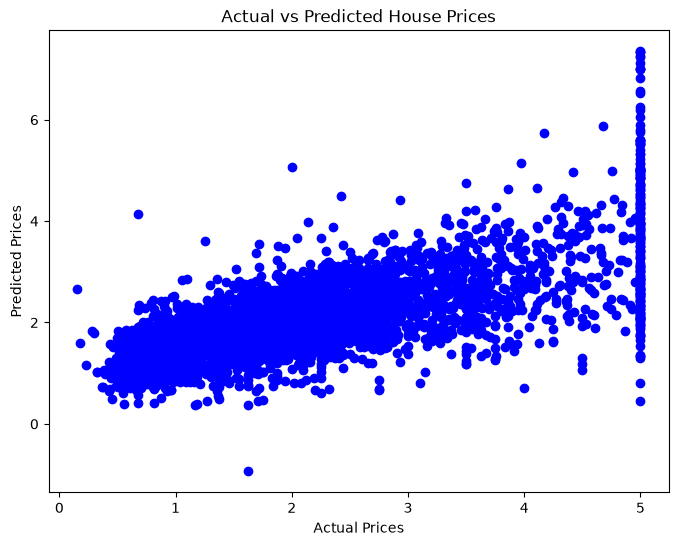

In [9]:
# Scatter plot of Actual vs Predicted prices

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, color="blue")

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

## What does the R² Score mean?

The R² score tells us how well the model explains the changes in house prices.

For example, if the R² score is 0.60, it means the model can explain about 60% of the differences in house prices using the selected features.

The remaining variation is caused by other factors that are not included in the model.

A higher R² score generally indicates a better-performing model.